In [1]:
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_134963/3720270093.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('binary')


Text(107.84722222222221, 0.5, 'Erosion (m)')

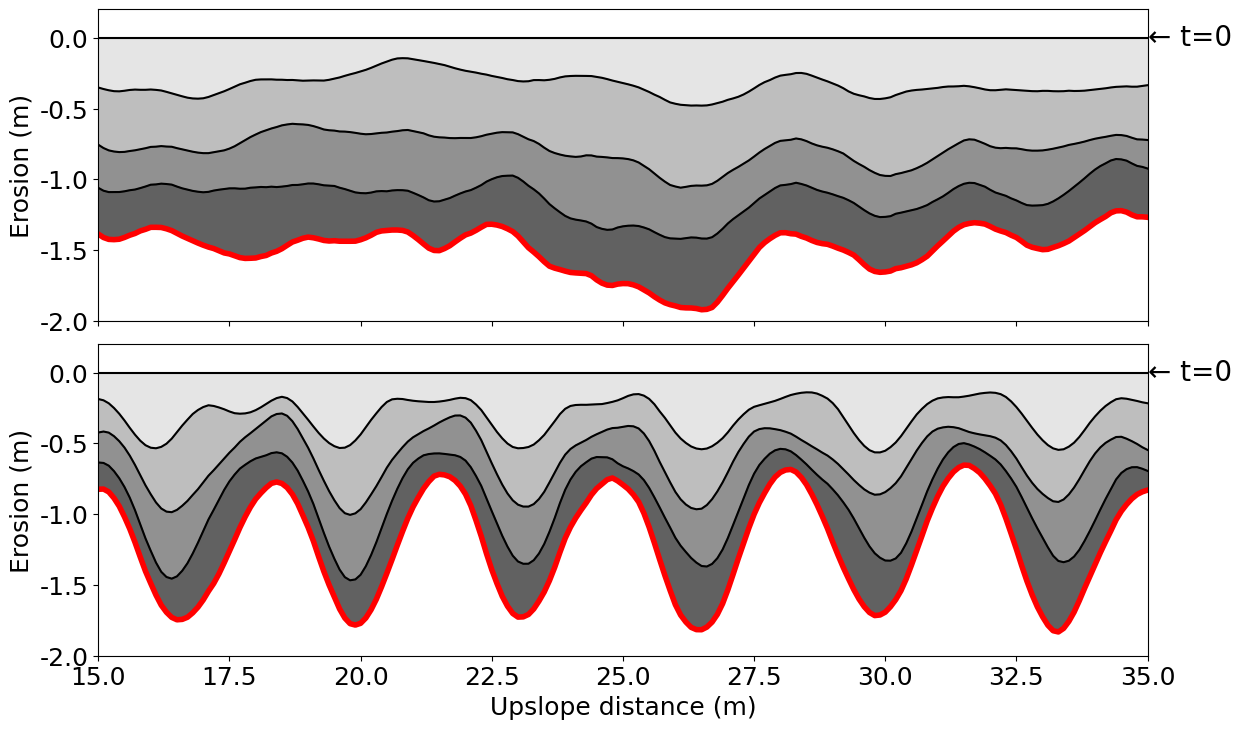

In [ ]:
temporal1 = np.load('fig07/noterracette_temporal.npy')
temporal2 = np.load('fig07/terracette_temporal.npy')
time_steps1 = np.shape(temporal1)[0]
time_steps2 = np.shape(temporal2)[0]
subset1 = np.linspace(0, time_steps1-1, 5, endpoint=True).astype(int)
subset2 = np.linspace(0, time_steps2-1, 5, endpoint=True).astype(int)
alphas = np.linspace(0.2, 1, 5, endpoint=True)
cmap = cm.get_cmap('binary')
min_color = cmap(alphas)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12,7), sharex=True)
for i in range(5):
    #ax1.plot(temporal1[subset1[i], :] - temporal1[0, :], alpha=alphas[i], c='k')
    if i == 4: 
        ax1.plot(temporal1[subset1[i], :] - temporal1[0, :], c='r', lw=4)
        ax2.plot(temporal2[subset2[i], :] - temporal2[0, :], c='r', lw=4)
        ax1.fill_between(np.arange(np.shape(temporal1)[1]), temporal1[subset1[i], :] - temporal1[0, :], np.ones(np.shape(temporal1)[1])*-20, color='white', alpha=1)
        ax2.fill_between(np.arange(np.shape(temporal2)[1]), temporal2[subset2[i], :] - temporal2[0, :], np.ones(np.shape(temporal2)[1])*-20, color='white', alpha=1) 
    else: 
        ax1.plot(temporal1[subset1[i], :] - temporal1[0, :], c='k')
        ax2.plot(temporal2[subset2[i], :] - temporal2[0, :], c='k')
        ax1.fill_between(np.arange(np.shape(temporal1)[1]), temporal1[subset1[i], :] - temporal1[0, :], np.ones(np.shape(temporal1)[1])*-20, color=min_color[i], alpha=0.5)
        ax2.fill_between(np.arange(np.shape(temporal2)[1]), temporal2[subset2[i], :] - temporal2[0, :], np.ones(np.shape(temporal2)[1])*-20, color=min_color[i], alpha=0.5) 
    
    if i == 0: 
        temp = temporal1[subset1[i], :] - temporal1[0, :]
        #ax1.text(351, temp[350], f'←{25*i}%', ha='left', va='center', fontsize=14)
        ax1.text(350, temp[350], f'← t={subset1[i]}', ha='left', va='center', fontsize=20)
        
        temp = temporal2[subset2[i], :] - temporal2[0, :]
        #ax2.text(351, temp[350], f'←{25*i}%', ha='left', va='center', fontsize=14)
        ax2.text(350, temp[350], f'← t={subset2[i]}', ha='left', va='center', fontsize=20)
        #ax1.text(352, -0.5, 'test')
        

plt.xlim(150, 350)
ax1.set_ylim(-20, 2)
ax2.set_ylim(-20, 2)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/10:.1f}'))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/10:.1f}'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'{val/10:.1f}'))
plt.tight_layout()
ax2.xaxis.set_tick_params(labelsize=18)
ax2.yaxis.set_tick_params(labelsize=18)
ax1.yaxis.set_tick_params(labelsize=18)
ax2.set_xlabel('Upslope distance (m)', fontsize=18)
ax1.set_ylabel('Erosion (m)', fontsize=18)
ax2.set_ylabel('Erosion (m)', fontsize=18)

In [3]:
sigmas = np.linspace(0, 45, 19)
betas = np.linspace(0, 60, 25)
repeat = 1
image = np.zeros((len(sigmas), len(betas)))

for i, sigma in enumerate(sigmas): 
    for j, beta in enumerate(betas): 

        #[mean_coherence, corr, prominence, lag, temp_entropy, angle_coh]
        metrics = np.load(f'fig07/{sigma}_{beta}_{repeat}_metrics.npy')
        image[i,j] = metrics[0]

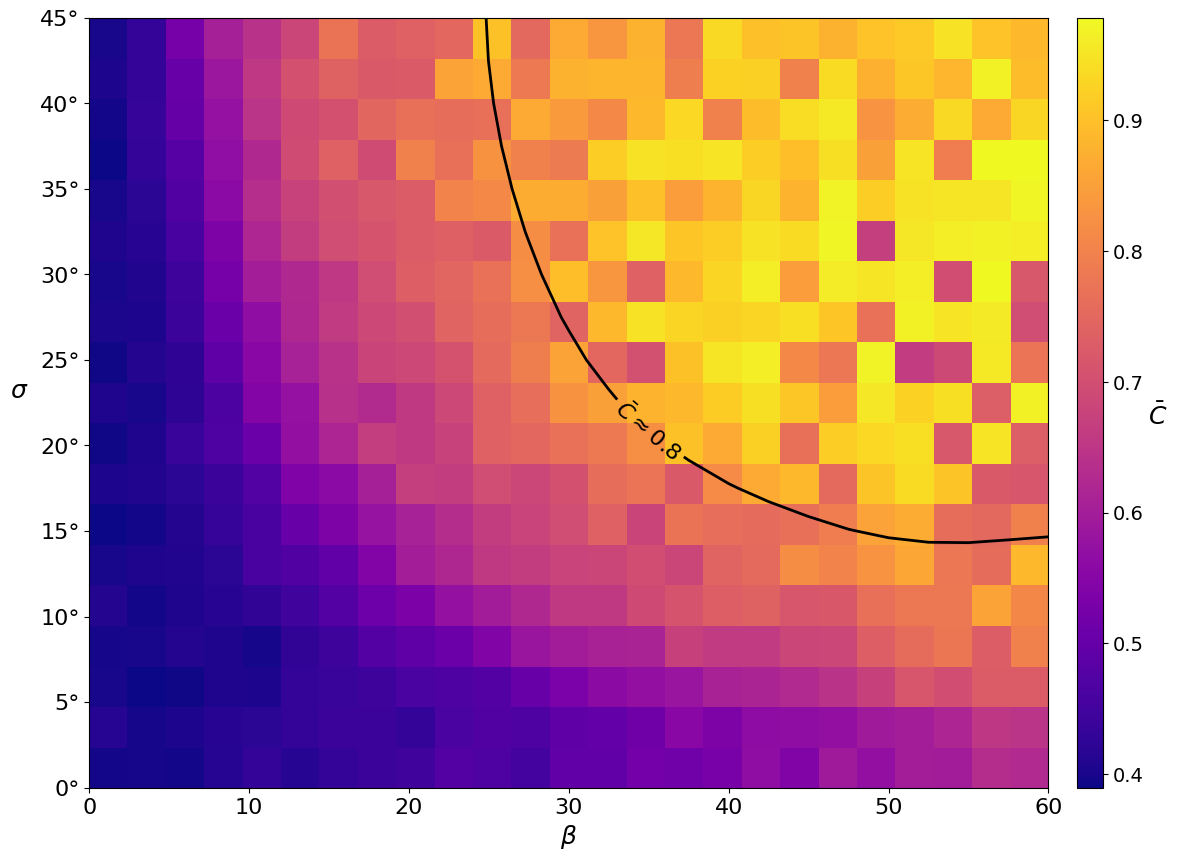

In [4]:
from scipy.ndimage import gaussian_filter

# Parameter grids
sigmas = np.linspace(0, 45, 19)
betas = np.linspace(0, 60, 25)
X, Y = np.meshgrid(betas, sigmas)

# 1. Smooth the data with a Gaussian filter (tune sigma to desired smoothness)
smoothed_image = gaussian_filter(image, sigma=2.5)

plt.figure(figsize=(15, 10))

# 2. Plot the original (unsmoothed) heatmap
plt.imshow(
    #smoothed_image,
    image, 
    origin='lower',
    extent=[betas.min(), betas.max(), sigmas.min(), sigmas.max()],
    aspect='auto',
    cmap='plasma'
)
cbar = plt.colorbar(label=r'$\bar{C}$', aspect=30, location='right', pad=0.025)
plt.xlabel(r'$\beta$', fontsize=18)
plt.xticks(fontsize=16)
plt.ylabel(r'$\sigma$', fontsize=18, rotation=0, labelpad=15)
custom_labels = ['0°', '5°', '10°', '15°', '20°', '25°', '30°', '35°', '40°', '45°']
plt.yticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 45], labels=custom_labels, fontsize=16)

# 3. Overlay the contour at coherence=0.8 on the smoothed data
cs = plt.contour(
    X, Y, 
    smoothed_image, 
    levels=[0.8],      # the coherence level of interest
    colors='black', 
    linewidths=2
)
plt.clabel(cs, fmt=r'$\bar{C} \approx 0.8$', fontsize=16)
cbar.ax.tick_params(labelsize=14) 
cbar.set_label(r'$\bar{C}$', fontsize=18, rotation=0, labelpad=10) 
plt.show()


10.0 10.0


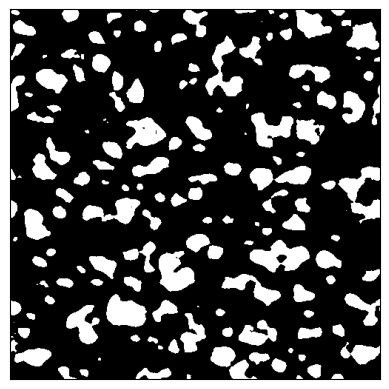

10.0 35.0


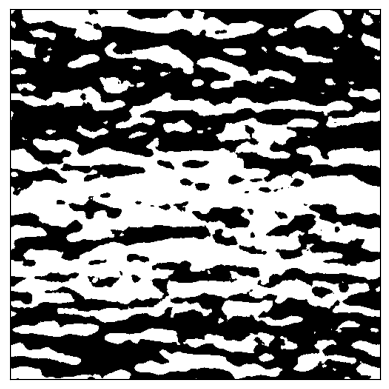

25.0 20.0


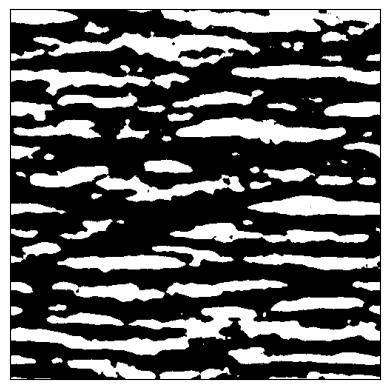

40.0 35.0


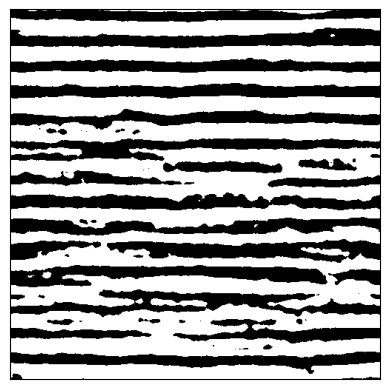

40.0 5.0


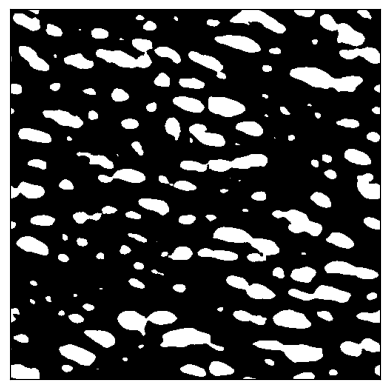

50.0 0.0


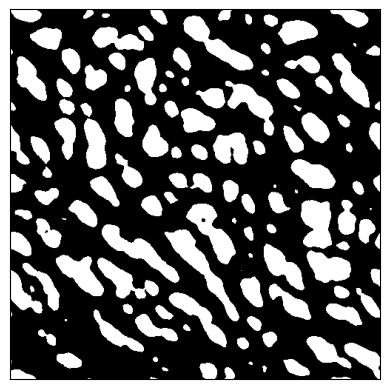

50.0 25.0


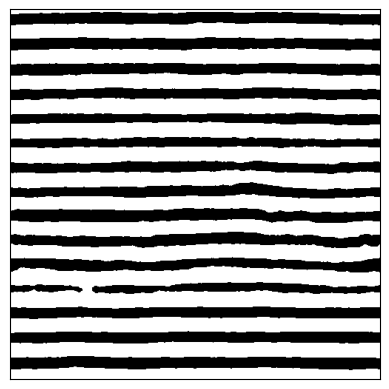

In [5]:
sigmas = [10.0, 35.0, 20.0, 35.0, 5.0, 0.0, 25.0]
betas = [10.0, 10.0, 25.0, 40.0, 40.0, 50.0, 50.0]

for i in range(len(sigmas)): 
    deviation = np.load(f'fig07/{sigmas[i]}_{betas[i]}_1.npy')
    deviation = deviation - np.min(deviation)
    temp = np.max(deviation)/2
    mask = deviation > temp

    temp = deviation.copy()
    temp[mask] = 1
    temp[~mask] = 0
    print(betas[i], sigmas[i])
    plt.imshow(temp, origin='lower', cmap='binary')
    plt.xticks([])
    plt.yticks([])
    plt.show()